In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

sns.set()

In [4]:
df = pd.read_csv(Path("../") / "results" / "classification_results_old.csv")
df

,subject,dataset,model,epoch_window,accuracy
0,1,Lee2019_MI,Deep4Net,w_00_30,0.83000
1,1,Lee2019_MI,Deep4Net,w_05_35,0.77000
2,2,Lee2019_MI,Deep4Net,w_00_30,0.79000
3,2,Lee2019_MI,Deep4Net,w_05_35,0.74000
4,3,Lee2019_MI,Deep4Net,w_00_30,0.84000
...,...,...,...,...,...
551,83,Dreyer2023,REVE,w_00_40,0.66875
552,84,Dreyer2023,REVE,w_00_40,0.89375
553,85,Dreyer2023,REVE,w_00_40,0.83750
554,86,Dreyer2023,REVE,w_00_40,0.83750


In [32]:
models = ["Deep4Net", "REVE"]
settings = {
    "Dreyer2023": ["w_00_40", "w_05_45"],
    "Lee2019_MI": ["w_00_30", "w_05_35"],
}

diff_dict = {}

for model in models:
    for dataset, setting in settings.items():
        df_single = df[
            (df["dataset"] == dataset) &
            (df["model"] == model)
            ]

        #print(df_single)

        a = df_single[df_single["epoch_window"] == setting[0]].sort_values("subject")
        b = df_single[df_single["epoch_window"] == setting[1]].sort_values("subject")

        diff_dict["subject"] = a["subject"].tolist()
        diff_dict["dataset"] = [dataset for _ in range(len(a))]
        diff_dict["model"] = [model for _ in range(len(a))]
        diff_dict["diff"] = a["accuracy"].to_numpy() - b["accuracy"].to_numpy()

diff_df = pd.DataFrame(diff_dict)
diff_df

#diff_df = diff_df.sort_values("diff")
#print(diff_df)


,subject,dataset,model,diff
0,1,Lee2019_MI,REVE,-0.05
1,2,Lee2019_MI,REVE,0.11
2,3,Lee2019_MI,REVE,0.00
3,4,Lee2019_MI,REVE,0.12
4,5,Lee2019_MI,REVE,-0.06
5,6,Lee2019_MI,REVE,0.10
6,7,Lee2019_MI,REVE,0.06
7,8,Lee2019_MI,REVE,-0.01
8,9,Lee2019_MI,REVE,-0.08
9,10,Lee2019_MI,REVE,-0.03


In [5]:
save_base = Path("./figures")
save_base.mkdir(exist_ok=True)

enable_title = False

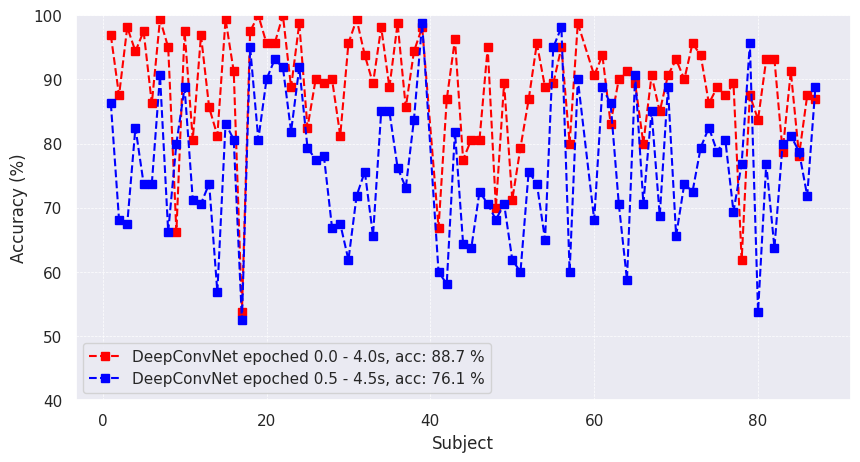

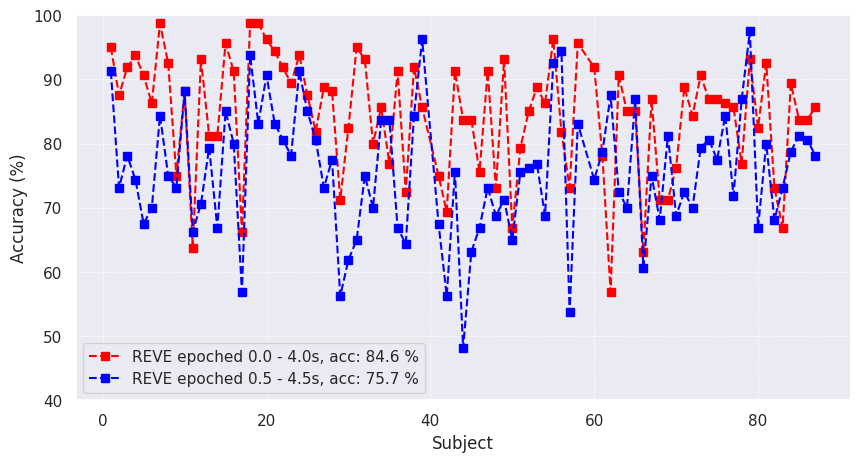

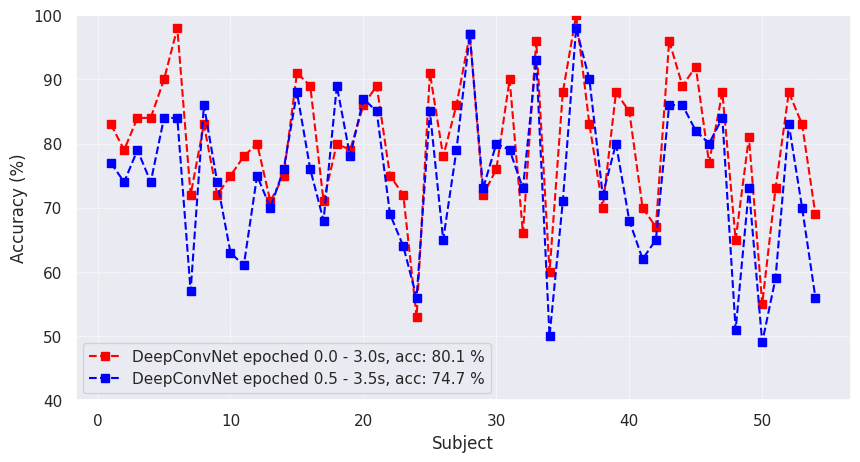

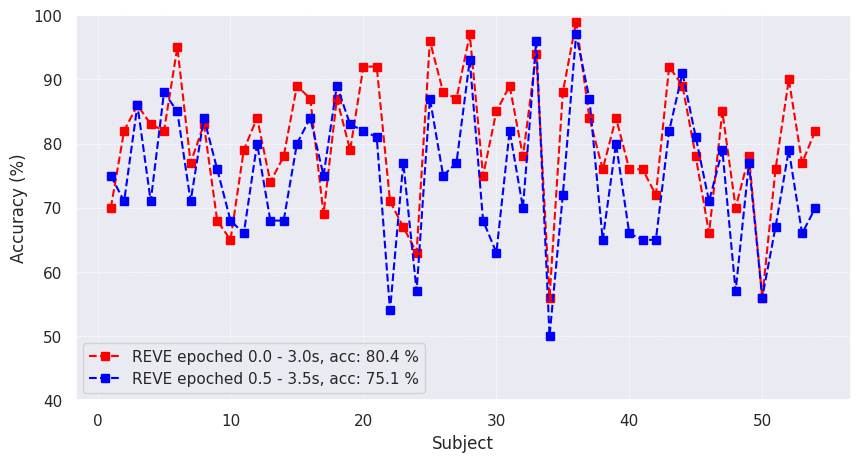

In [6]:
def win_name(window):
    t1 = window.split("_")[1]
    t2 = window.split("_")[2]
    t1 = f"{t1[0]}.{t1[1]}"
    t2 = f"{t2[0]}.{t2[1]}"

    return float(t1), float(t2)


def plot_accuracy(df, dataset, model, windows=["w_00_40", "w_05_45"], colors=["red", "blue"], ax=None, model_name=None,
                  mode=None):
    if ax is None:
        _, ax = plt.subplots()

    df = df[(df["dataset"] == dataset) & (df["model"] == model)]

    if mode is not None:
        df = df[df["mode"] == mode]

    if "session" in list(df.columns):
        df = df.groupby(["mode", "dataset", "subject", "model", "epoch_window"])["accuracy"].mean().reset_index()

    for window, color in zip(windows, colors):
        df_window = df[df["epoch_window"] == window]

        df_window = df_window.sort_values("subject")
        mean_acc = df_window["accuracy"].mean()

        t1, t2 = win_name(window)

        #if model == "Deep4Net":
        #    model_name = "DeepConvNet"

        ax.plot(df_window["subject"], df_window["accuracy"] * 100, marker="s", linestyle="--",
                label=f"{model_name} epoched {t1} - {t2}s, acc: {mean_acc * 100:.1f} %"
                , color=color)

    ax.set_ylim([40, 100])
    ax.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Subject")


fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023", model="Deep4Net", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="DeepConvNet")
if enable_title:
    fig.suptitle("Dreyer2023 (DeepConvNet)")
fig.savefig(save_base / "Dreyer2023_DeepConvNet.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023", model="REVE", windows=["w_00_40", "w_05_45"], ax=ax, model_name="REVE")
if enable_title:
    fig.suptitle("Dreyer2023 (REVE)")
fig.savefig(save_base / "Dreyer2023_REVE.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Lee2019_MI", model="Deep4Net", windows=["w_00_30", "w_05_35"], ax=ax,
              model_name="DeepConvNet")
if enable_title:
    fig.suptitle("Lee2019_MI (DeepConvNet)")
fig.savefig(save_base / "Lee2019_MI_DeepConvNet.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Lee2019_MI", model="REVE", windows=["w_00_30", "w_05_35"], ax=ax, model_name="REVE")
if enable_title:
    fig.suptitle("Lee2019_MI (REVE)")
fig.savefig(save_base / "Lee2019_MI_REVE.png", dpi=300)



# CSP + LDA

In [4]:
df_csp = pd.read_csv(Path("../") / "results" / "classification_results_csp_lda.csv")
df_csp


,mode,dataset,subject,session,model,epoch_window,accuracy
0,within_user,Lee2019_MI,1,1,CSP_LDA,w_05_35,0.52000
1,within_user,Lee2019_MI,1,2,CSP_LDA,w_05_35,0.46000
2,within_user,Dreyer2023,1,1,CSP_LDA,w_00_40,0.76875
3,within_user,Dreyer2023,1,1,CSP_LDA,w_05_45,0.83750
4,within_user,Lee2019_MI,1,1,CSP_LDA,w_00_30,0.56000
...,...,...,...,...,...,...,...
767,cross_user,Dreyer2023,86,1,CSP_LDA,w_05_45,0.51250
768,within_user,Dreyer2023,87,1,CSP_LDA,w_05_45,0.84375
769,cross_user,Dreyer2023,87,1,CSP_LDA,w_00_40,0.83125
770,cross_user,Dreyer2023,87,1,CSP_LDA,w_05_45,0.90625


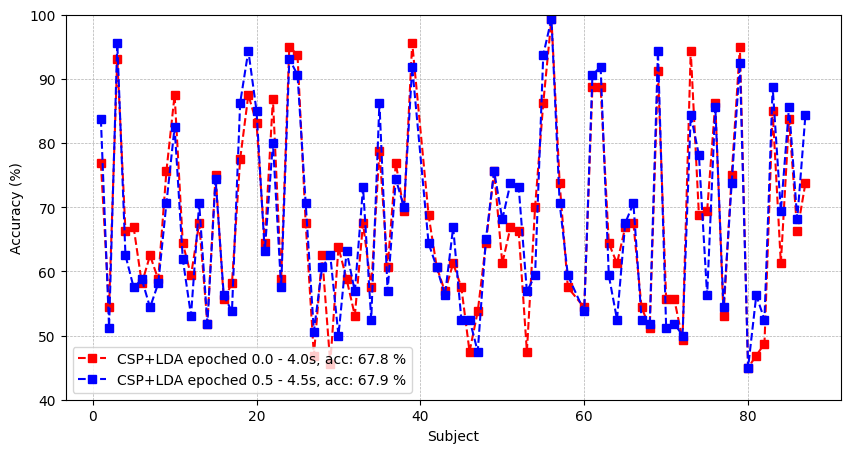

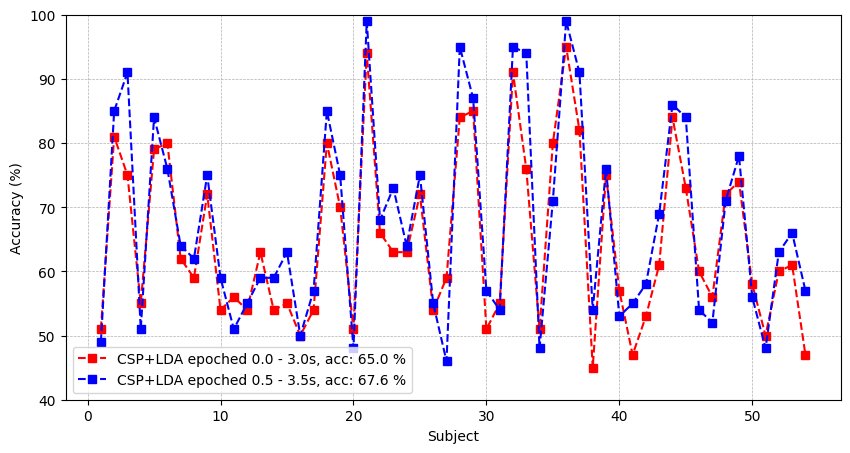

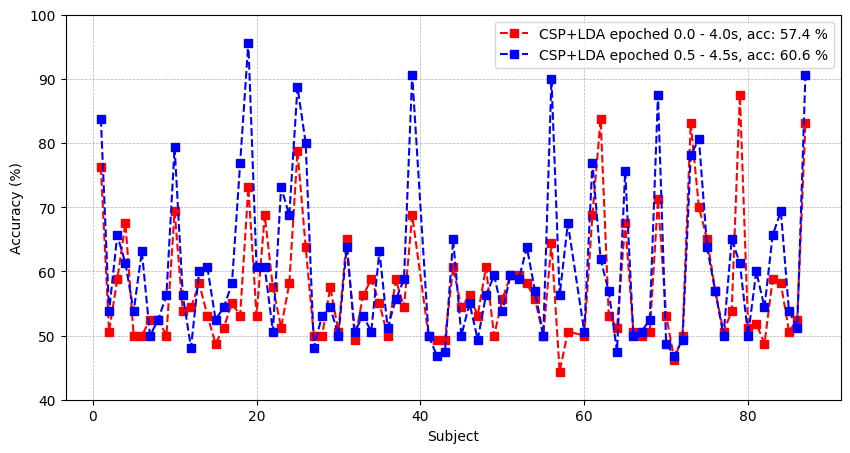

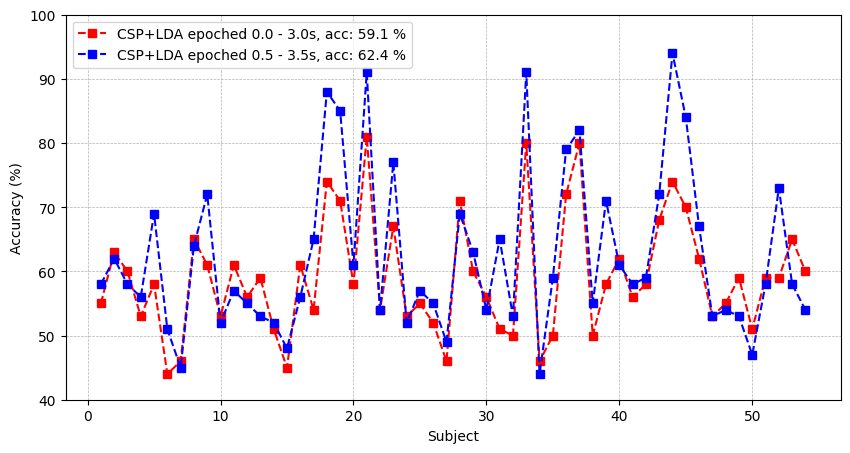

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Dreyer2023", model="CSP_LDA", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="CSP+LDA", mode="within_user")
if enable_title:
    fig.suptitle("Dreyer2023 (CSP+LDA) - Within-Subject approach")
fig.savefig(save_base / "Dreyer2023_CSP_LDA_within.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Lee2019_MI", model="CSP_LDA", windows=["w_00_30", "w_05_35"], ax=ax,
              model_name="CSP+LDA", mode="within_user")
if enable_title:
    fig.suptitle("Lee2019_MI (CSP+LDA) - Within-Subject approach")
fig.savefig(save_base / "Lee2019_MI_CSP_LDA_within.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Dreyer2023", model="CSP_LDA", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="CSP+LDA", mode="cross_user")
if enable_title:
    fig.suptitle("Dreyer2023 (CSP+LDA) - Cross-Subject approach")
fig.savefig(save_base / "Dreyer2023_CSP_LDA_cross.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Lee2019_MI", model="CSP_LDA", windows=["w_00_30", "w_05_35"], ax=ax,
              model_name="CSP+LDA", mode="cross_user")
if enable_title:
    fig.suptitle("Lee2019_MI (CSP+LDA) - Cross-Subject approach")
fig.savefig(save_base / "Lee2019_MI_CSP_LDA_cross.png", dpi=300)
